Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and global variables

In [2]:
# Constants
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_Neu\\Expression_TE_DESeq_Neu.csv"
DEA_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Rodrigues2020_Neu\\DEA_TE_DESeq_Neu.csv"
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\Clinical_Data_Rodrigues20.csv"
INTERGENIC_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Rodrigues2020\\TE_Intergenic_With_Distances_Neu.bed"

# Variables
expression_df = None
dea_df = None
genes_of_interest = None

DEA - Import

In [3]:
dea_df = pd.read_csv(DEA_FILE)
dea_df = dea_df.rename(columns={'Unnamed: 0': 'TE'})
dea_df = dea_df.dropna(subset=['padj'])
dea_df.head()

,TE,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,TE_HERVIP10B3-int_dup212,1426.332444,-9.342063,0.564804,-16.540365,1.878814e-61,3.806740e-56
1,TE_HERVIP10B3-int_dup14,938.457013,-8.077251,0.491703,-16.427083,1.224067e-60,1.240065e-55
2,TE_L1HS_dup821,2275.588816,-5.607133,0.426684,-13.141185,1.912076e-39,1.291378e-34
3,TE_HERVIP10B3-int_dup211,503.097309,-8.474605,0.653204,-12.973910,1.720258e-38,8.713711e-34
4,TE_MLT1B_dup15290,511.378993,-8.141095,0.630677,-12.908504,4.030537e-38,1.633286e-33


Expression - Import

In [4]:
expression_df = pd.read_csv(EXPRESSION_FILE)
expression_df.rename(columns = {'Unnamed: 0' : 'TE'}, inplace = True)
expression_df.head()

,TE,Neu_RTT_rep1,Neu_RTT_rep2,Neu_RTT_rep3,Neu_WT_rep1,Neu_WT_rep2,Neu_WT_rep3
0,TE_L3_dup1,9,0,14,0,9,0
1,TE_MIR_dup1,1,3,5,0,8,0
2,TE_L2b_dup1,2,0,5,0,6,0
3,TE_L2b_dup2,3,0,8,0,2,0
4,TE_MIR1_Amn_dup1,0,0,5,0,8,6


Volcano plot

Classification
Non-significant    201011
Up-regulated          950
Down-regulated        653
Name: count, dtype: int64
1603
Total tes:
671132
50480
          0          1          2                    TE      4  5          6  \
0      chr1    1607336    1607638       TE_AluSx1_dup85   2465  -        Alu   
1      chr1    1608273    1608438          TE_FRAM_dup6   1104  +        Alu   
2      chr1    1608440    1608756        TE_AluJo_dup59   1989  +        Alu   
3      chr1    1610181    1610533         TE_THE1C_dup5   2197  +  ERVL-MaLR   
4      chr1    4997262    4997564      TE_AluSx1_dup210   2187  -        Alu   
...     ...        ...        ...                   ...    ... ..        ...   
12132  chrX  155443188  155444681     TE_L1MA4A_dup6245   9511  +         L1   
12133  chrX  155444867  155448478     TE_L1MA4A_dup6246  13870  +         L1   
12134  chrX  155451214  155452797  TE_THE1B-int_dup4252  11626  +  ERVL-MaLR   
12135  chrY    6748888    6749855     TE_LTR5_Hs_dup

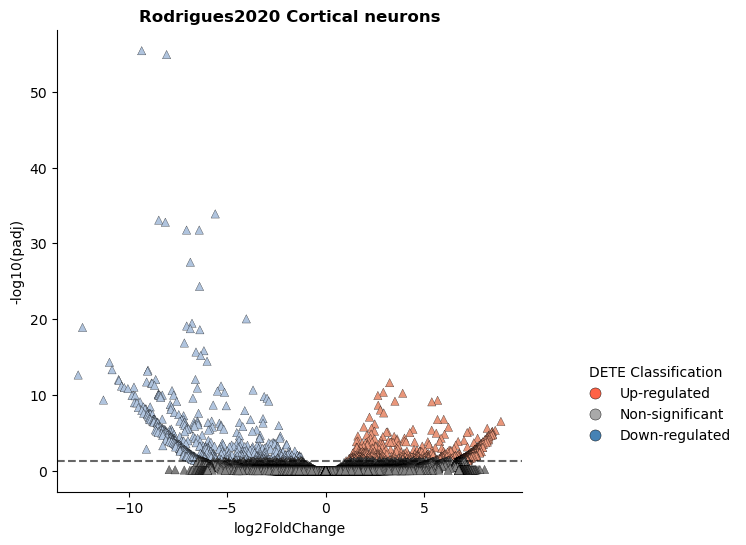

In [10]:

# Organizes the classification, according to the defined values
def organize_classification():
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < -0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )

# Sets the graph's reference lines and labels
def set_lines_and_labels(ax):
    ax.axhline(y = -np.log10(0.05), color = 'black', linestyle = '--', alpha = 0.6)

    ax.set_title('Rodrigues2020 Cortical neurons', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('log2FoldChange')
    ax.set_ylabel('-log10(padj)')

# Gets the genes with the biggest change in expression
def get_genes_of_interest():
    top_up = dea_df.nlargest(5, 'log2FoldChange')['TE'].tolist()
    top_down = dea_df.nsmallest(5, 'log2FoldChange')['TE'].tolist()
    genes_of_interest = top_up + top_down

    dea_df['Classification'] = np.where(dea_df['TE'].isin(genes_of_interest), 
                                        'GOI_' + dea_df['Classification'],
                                        dea_df['Classification'])
    
    return genes_of_interest

# Sets the genes of interest's names on the graph
def set_genes_of_interest_legend(ax):
    global genes_of_interest
    genes_of_interest = get_genes_of_interest()
    texts = []
    for i, row in dea_df.iterrows():
        if row['TE'] in genes_of_interest:
            texts.append(ax.text(row['log2FoldChange'], row['-log10(padj)'], row['TE'],
                         fontsize = 7, color = 'black', fontweight = 'semibold'))
            
    adjust_text(texts, expand_points = (1.5, 1.5), arrowprops = dict(arrowstyle = '-', color = 'black', lw = 0.8), save_steps = False)
    print(texts)

# Sets the main chart legend on the plot
def set_plot_legends(ax):
    #set_genes_of_interest_legend(ax)
    legend_elements = [Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'tomato',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3, 
                            label = 'Up-regulated'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'darkgray',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Non-significant'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'steelblue',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Down-regulated')]
    ax.legend(handles = legend_elements, title = 'DETE Classification', bbox_to_anchor = (1.1, 0.3), frameon = False)

# Main function, gets the volcano plot
def get_volcano_plot():
    organize_classification() # Organiza-se primeiro a tabela com a classificação
    print(dea_df['Classification'].value_counts())
    subset = dea_df[dea_df['Classification'] != 'Non-significant']
    print(len(subset))
    print('Total tes:')
    print(len(expression_df))
    
    intergenic_df = pd.read_csv(INTERGENIC_FILE, sep = '\t', header = None, comment = '#')
    intergenic_df = intergenic_df[intergenic_df.iloc[:, -1] > 4000]
    print(intergenic_df.shape[0])

    intergenic_df = intergenic_df.rename(columns = {intergenic_df.columns[3] : 'TE'})
    intergenic_dete_df = intergenic_df.merge(dea_df, on = 'TE', how = 'inner')
    print(intergenic_dete_df)
    intergenic_dete_df = intergenic_dete_df[intergenic_dete_df['Classification'] != 'Non-significant']
    print('intergenic dete')
    print(intergenic_dete_df.shape[0])
    

    fig, ax = plt.subplots(figsize = (6, 6)) # Criamos o gráfico
    
    palette_dea = {'GOI_Up-regulated' : 'tomato',
                   'GOI_Down-regulated' : 'steelblue',
                   'Up-regulated' : 'darksalmon',
                   'Down-regulated' : 'lightsteelblue',
                   'Non-significant' : 'gray'}
    
    sns.scatterplot(data = dea_df,  
                    x = 'log2FoldChange', 
                    y = '-log10(padj)',
                    palette = palette_dea, 
                    hue = 'Classification', 
                    edgecolor = 'black',
                    linewidth = 0.2, 
                    legend = False,
                    marker = '^')
    
    set_lines_and_labels(ax) # Colocamos as labels que queremos
    set_plot_legends(ax) # Colocamos as legendas por último
    sns.despine()
    plt.show()
    
get_volcano_plot()



PCA - Data frame

In [11]:
# Variables
TEs = expression_df.iloc[:, 0]
counts = expression_df.iloc[:, 1:]
clinical_data = pd.read_csv(CLINICAL_DATA, sep = ";")

# Process counts
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)

# Process clinical data
print(clinical_data.columns)
clinical_data = clinical_data[['Sample_Name', 'Condition', 'Run']]

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# PCA data frame
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample_Name', inplace = True)
pca_df = pca_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

pca_df.head()


Index(['Run', 'Cells', 'Cells_Abv', 'Sample_Description', 'Condition',
       'Sample_Name'],
      dtype='object')


,Sample_Name,PC1,PC2,Condition,Run
0,Neu_RTT_rep1,-126.946831,34.980695,RTT,SRR8314940
1,Neu_RTT_rep1,-126.946831,34.980695,RTT,SRR8314941
2,Neu_RTT_rep1,-126.946831,34.980695,RTT,SRR8314942
3,Neu_RTT_rep2,504.360212,776.447255,RTT,SRR8314968
4,Neu_RTT_rep2,504.360212,776.447255,RTT,SRR8314969


PCA - Graph

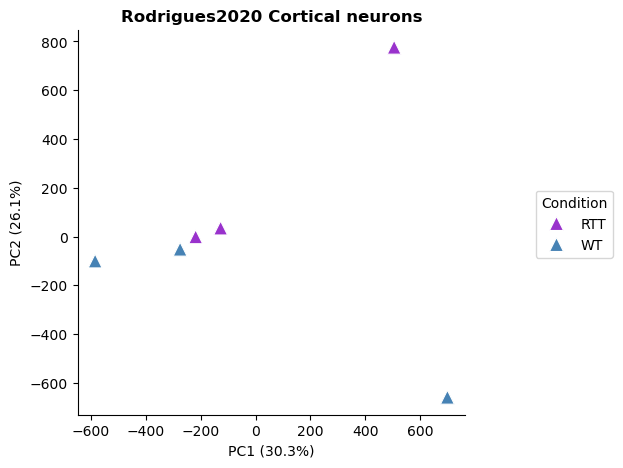

In [12]:
# Create figure
fig, ax = plt.subplots(figsize = (5,5))

palette_pca = {'WT' : 'steelblue',
               'RTT' : 'darkorchid'}

sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', palette = palette_pca, 
                hue = 'Condition', s = 100, marker = '^')


# Set labels and chart legend
ax.set_title('Rodrigues2020 Cortical neurons', fontweight = 'bold', fontsize = 12)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))

sns.despine()
plt.show()

Boxplot

    Sample_Name Condition         Run
0   NPC_WT_rep1        WT  SRR8314922
1   NPC_WT_rep1        WT  SRR8314923
2   NPC_WT_rep1        WT  SRR8314924
3  NPC_RTT_rep1       RTT  SRR8314928
4  NPC_RTT_rep1       RTT  SRR8314929


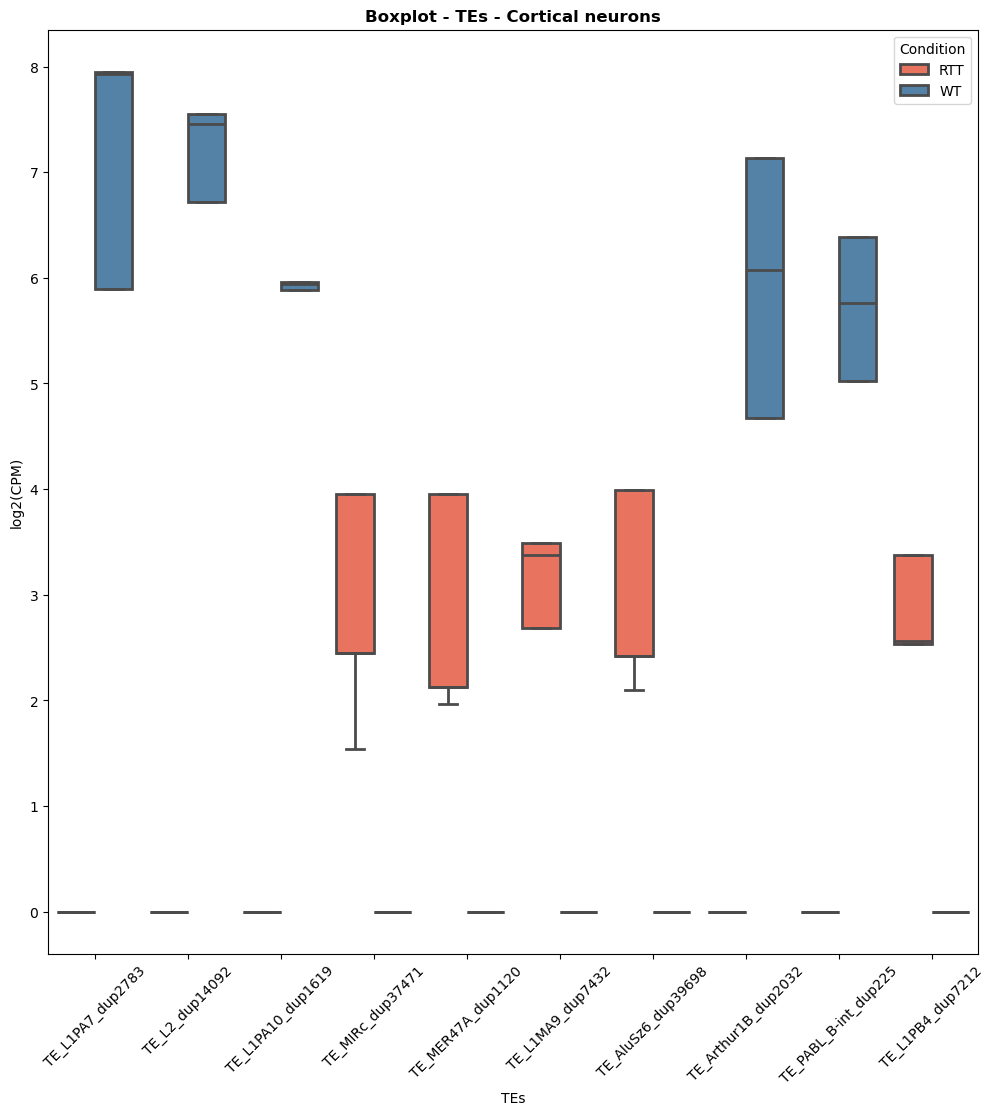

In [13]:
# Assemble the new table
log2cpm_df.insert(0, 'TE', TEs)
goi_df = log2cpm_df[log2cpm_df['TE'].isin(genes_of_interest)]

long_df = goi_df.melt(id_vars = 'TE', var_name = 'Sample_Name', value_name = 'log2(CPM)')
long_df = long_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

print(clinical_data.head())

# Assemble the plot

fig, ax = plt.subplots(figsize = (12, 12))

palette_boxplot = {'RTT' : 'tomato',
                   'WT' : 'steelblue'}

sns.boxplot(data = long_df, x = 'TE', y = 'log2(CPM)', hue = 'Condition', palette = palette_boxplot,
                fliersize = 2, linewidth = 2)

ax.set_title('Boxplot - TEs - Cortical neurons', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('TEs')
ax.set_ylabel('log2(CPM)')
ax.tick_params(axis = 'x', rotation = 45)

